# অধ্যায় ৫: মডেল মূল্যায়ন
## পাঠ ৫.৩: ইভালুয়েশন মেট্রিক্স

আজ আমরা শিখব মডেল মূল্যায়নের বিভিন্ন মেট্রিক্স সম্পর্কে। শুধু Accuracy দিয়ে মডেলের ভালো-মন্দ বোঝা যায় না—বিশেষ করে ইমব্যালেন্সড ডেটার জন্য।

### A. গল্প: রোগ নির্ণয়

ধরো, তুমি একটি রোগ নির্ণয়ের মডেল বানিয়েছ। রোগটি বিরল—১০০০ জনের মধ্যে মাত্র ১ জনের এই রোগ আছে।

যদি তোমার মডেল সবাইকে 'সুস্থ' বলে (অর্থাৎ কারোর রোগ ধরে না), তাহলে Accuracy হবে ৯৯৯/১০০০ = ৯৯.৯%!

কিন্তু এই মডেল কি ভালো? না—কারণ এটি আসলে রোগীকে চিহ্নিত করতেই পারে না! এখানেই Accuracy-র সীমাবদ্ধতা।

### B. কনফিউশন ম্যাট্রিক্স

কনফিউশন ম্যাট্রিক্স একটি টেবিল যা দেখায় মডেল কতগুলো সঠিক এবং ভুল পূর্বাভাস দিয়েছে।

| | পূর্বাভাস: নেগেটিভ | পূর্বাভাস: পজিটিভ |
|---|---|---|
| **আসল: নেগেটিভ** | True Negative (TN) | False Positive (FP) |
| **আসল: পজিটিভ** | False Negative (FN) | True Positive (TP) |

- **True Positive (TP):** সঠিকভাবে ধরা পজিটিভ (রোগী আছে, মডেল বলল আছে)
- **True Negative (TN):** সঠিকভাবে ধরা নেগেটিভ (রোগী নেই, মডেল বলল নেই)
- **False Positive (FP):** ভুলভাবে ধরা পজিটিভ (রোগী নেই, মডেল বলল আছে)—একে 'টাইপ ১ ত্রুটি' বলে
- **False Negative (FN):** ভুলভাবে ধরা নেগেটিভ (রোগী আছে, মডেল বলল নেই)—একে 'টাইপ ২ ত্রুটি' বলে

In [1]:
# প্রয়োজনীয় লাইব্রেরি
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)

# ইমব্যালেন্সড ডেটাসেট তৈরি
X, y = make_classification(
    n_samples=2000, n_features=5, n_informative=3,
    n_redundant=1, weights=[0.9, 0.1], random_state=42
)
print('ডেটাসেট:')
print(f'  ক্লাস 0 (নেগেটিভ): {np.sum(y == 0)} ({np.mean(y == 0)*100:.1f}%)')
print(f'  ক্লাস 1 (পজিটিভ): {np.sum(y == 1)} ({np.mean(y == 1)*100:.1f}%)')

ডেটাসেট:
  ক্লাস 0 (নেগেটিভ): 1794 (89.7%)
  ক্লাস 1 (পজিটিভ): 206 (10.3%)


### C. কনফিউশন ম্যাট্রিক্স দেখা

প্রথমে আমরা Logistic Regression ট্রেইন করি এবং কনফিউশন ম্যাট্রিক্স দেখি।

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2503 (\N{BENGALI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2455 (\N{BENGALI LETTER GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: User

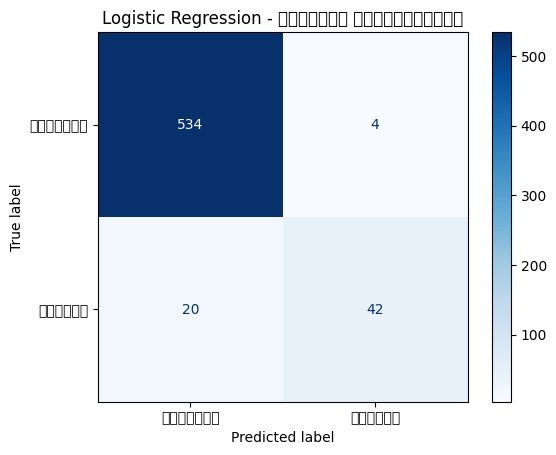

True Negative: 534, False Positive: 4
False Negative: 20, True Positive: 42

Accuracy: 0.9600


In [2]:
# ডেটা ভাগ করি
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# কনফিউশন ম্যাট্রিক্স
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['নেগেটিভ', 'পজিটিভ'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression - কনফিউশন ম্যাট্রিক্স')
plt.show()

TN, FP, FN, TP = cm.ravel()
print(f'True Negative: {TN}, False Positive: {FP}')
print(f'False Negative: {FN}, True Positive: {TP}')
print(f'\nAccuracy: {(TP+TN)/(TP+TN+FP+FN):.4f}')

### D. Precision, Recall, F1-Score

**Precision (প্রিসিশন):** মডেল যাদের 'পজিটিভ' বলেছে, তাদের মধ্যে কতজন সত্যিই পজিটিভ?
$$Precision = \frac{TP}{TP + FP}$$

অর্থাৎ, 'রোগী আছে' বলা রোগীদের মধ্যে প্রকৃত রোগীর অনুপাত। FP কমালে Precision বাড়ে।

**Recall (রিকল):** প্রকৃত পজিটিভদের কতজনকে মডেল চিহ্নিত করতে পেরেছে?
$$Recall = \frac{TP}{TP + FN}$$

অর্থাৎ, প্রকৃত রোগীদের মধ্যে কতজনকে শনাক্ত করা গেছে। FN কমালে Recall বাড়ে।

**F1-Score:** Precision এবং Recall-এর হারমোনিক গড়।
$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

**কখন কোন মেট্রিক ব্যবহার করব?**
- স্প্যাম ডিটেকশন: Precision গুরুত্বপূর্ণ (ভালো মেইলকে স্প্যাম বললে সমস্যা)
- রোগ নির্ণয়: Recall গুরুত্বপূর্ণ (রোগীকে সুস্থ বললে মারাত্মক)
- ব্যালেন্সড ডেটা: Accuracy বা F1-Score

In [3]:
# classification_report দেখি
print('Logistic Regression - Classification Report:')
print(classification_report(y_test, y_pred, target_names=['নেগেটিভ', 'পজিটিভ']))

# পৃথকভাবে মেট্রিক্স
print(f'\nAccuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred):.4f}')

Logistic Regression - Classification Report:
              precision    recall  f1-score   support

     নেগেটিভ       0.96      0.99      0.98       538
      পজিটিভ       0.91      0.68      0.78        62

    accuracy                           0.96       600
   macro avg       0.94      0.83      0.88       600
weighted avg       0.96      0.96      0.96       600


Accuracy:  0.9600
Precision: 0.9130
Recall:    0.6774
F1-Score:  0.7778


In [4]:
# বিভিন্ন ক্লাসিফায়ারের তুলনা
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    results.append({
        'মডেল': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0)
    })
print('মডেল তুলনা:')
print(f'{"মডেল":25s} {"Accuracy":10s} {"Precision":10s} {"Recall":10s} {"F1":10s}')
print('-' * 65)
for r in results:
    print(f'{r["মডেল"]:25s} {r["Accuracy"]:10.4f} {r["Precision"]:10.4f} {r["Recall"]:10.4f} {r["F1-Score"]:10.4f}')
print('\n→ দেখো, Accuracy প্রায় সব মডেলের জন্য বেশি, কিন্তু Precision/Recall ভিন্ন!')

মডেল তুলনা:
মডেল                      Accuracy   Precision  Recall     F1        
-----------------------------------------------------------------
Logistic Regression           0.9600     0.9130     0.6774     0.7778
KNN (k=5)                     0.9583     0.8627     0.7097     0.7788
Random Forest                 0.9733     0.8710     0.8710     0.8710

→ দেখো, Accuracy প্রায় সব মডেলের জন্য বেশি, কিন্তু Precision/Recall ভিন্ন!


### E. ইমব্যালেন্সড ডেটায় Accuracy-র সমস্যা

উপরে দেখা গেল Accuracy সব মডেলের জন্যই বেশি (৯০%+)। কারণ ডেটার ৯০% নেগেটিভ। একটি 'বোকা' মডেল যে সবাইকে নেগেটিভ বলে, সেটির Accuracy-ও হবে ৯০%!

এজন্য ইমব্যালেন্সড ডেটার জন্য Precision, Recall, F1-Score বা ROC-AUC-এর মতো মেট্রিক ব্যবহার করা উচিত।

একটি 'বোকা' মডেল (সবাইকে নেগেটিভ বলে):
- Precision = ০ (কোনো পজিটিভ প্রেডিকশন নেই)
- Recall = ০ (কোনো পজিটিভ শনাক্ত করতে পারেনি)
- F1 = ০
- কিন্তু Accuracy = ৯০%!

এখানেই বোঝা যায় Accuracy কেন যথেষ্ট নয়।

In [5]:
# 'বোকা' মডেল বনাম প্রকৃত মডেল
y_pred_dumb = np.zeros_like(y_test)  # সবাইকে নেগেটিভ বলি

print('"বোকা" মডেল (সবাইকে নেগেটিভ):')
print(f'  Accuracy:  {accuracy_score(y_test, y_pred_dumb):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_dumb, zero_division=0):.4f}')
print(f'  Recall:    {recall_score(y_test, y_pred_dumb, zero_division=0):.4f}')
print(f'  F1-Score:  {f1_score(y_test, y_pred_dumb, zero_division=0):.4f}')
print('\nতুলনা করো:')
print(f'  বোকা মডেলের Accuracy = {accuracy_score(y_test, y_pred_dumb):.4f}')
print(f'  Logistic Regression Accuracy = {accuracy_score(y_test, y_pred):.4f}')
print('\n→ Accuracy কাছাকাছি হলেও Recall এবং F1 বিশাল পার্থক্য!')

"বোকা" মডেল (সবাইকে নেগেটিভ):
  Accuracy:  0.8967
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000

তুলনা করো:
  বোকা মডেলের Accuracy = 0.8967
  Logistic Regression Accuracy = 0.9733

→ Accuracy কাছাকাছি হলেও Recall এবং F1 বিশাল পার্থক্য!


### F. Iris ডেটাসেটে মেট্রিক্স

এখন আমরা ব্যালেন্সড Iris ডেটাসেটে মেট্রিক্স দেখব। এখানে ৩টি ক্লাস, প্রতিটিতে সমান সংখ্যক নমুনা।

Iris ডেটাসেট - Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2453 (\N{BENGALI LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWa

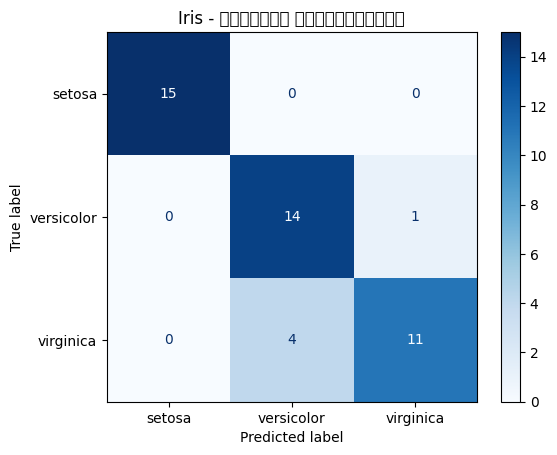

In [6]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris, y_iris = iris.data, iris.target

X_tr, X_te, y_tr, y_te = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_tr, y_tr)
y_pred_iris = rf.predict(X_te)
print('Iris ডেটাসেট - Classification Report:')
print(classification_report(y_te, y_pred_iris, target_names=iris.target_names))

# কনফিউশন ম্যাট্রিক্স
cm = confusion_matrix(y_te, y_pred_iris)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title('Iris - কনফিউশন ম্যাট্রিক্স')
plt.show()

### G. মেট্রিক্স বাছাইয়ের নির্দেশিকা

| পরিস্থিতি | প্রধান মেট্রিক | কারণ |
|-----------|----------------|------|
| ব্যালেন্সড ক্লাস | Accuracy | সব ক্লাস সমান গুরুত্বপূর্ণ |
| ইমব্যালেন্সড, FP ক্ষতিকর | Precision | ভুল পজিটিভ এড়াতে চাই |
| ইমব্যালেন্সড, FN ক্ষতিকর | Recall | পজিটিভ মিস না করতে চাই |
| ব্যালেন্সড গুরুত্ব | F1-Score | Precision ও Recall-এর সমঝোতা |
| মাল্টি-ক্লাস | macro/weighted avg | সব ক্লাসের গড় |

### H. তুমি কি বুঝতে পেরেছ?

**প্রশ্ন ১:** Accuracy, Precision এবং Recall-এর মধ্যে পার্থক্য কী?

**প্রশ্ন ২:** ইমব্যালেন্সড ডেটাসেটে কেন Accuracy যথেষ্ট নয়?

**প্রশ্ন ৩:** কনফিউশন ম্যাট্রিক্সের চারটি উপাদানের নাম বলো।

**প্রশ্ন ৪:** F1-Score কখন সবচেয়ে উপযোগী?

### I. সারসংক্ষেপ

আজ আমরা শিখলাম:
✅ Accuracy সবার জন্য ভালো নয়—বিশেষ করে ইমব্যালেন্সড ডেটায়
✅ কনফিউশন ম্যাট্রিক্স TP, TN, FP, FN দেখায়
✅ Precision = TP/(TP+FP), Recall = TP/(TP+FN)
✅ F1-Score Precision ও Recall-এর সমন্বয়
✅ classification_report সব মেট্রিক একসাথে দেখায়
✅ মেট্রিক বাছাই সমস্যার ধরনের ওপর নির্ভর করে

পরবর্তী পাঠে আমরা প্রিসিশন-রিকল কার্ভ এবং ROC কার্ভ নিয়ে শিখব!